**Формулировка гипотез**

Гипотеза 1: Существуют пользователи с аномально высокой частотой действий, не соответствующей штатным бизнес-процессам

Метод проверки: Анализ распределения количества действий по user_id, выявление выбросов через IQR/Z-score

Гипотеза 2: Некоторые пользователи совершают действия преимущественно во внерабочее время (ночь, выходные), что может указывать на несанкционированный доступ

Метод проверки: Анализ временных меток: выделение часов/дней недели, расчет доли emergency-действий

Гипотеза 3: Отсутствующие или шаблонные комментарии к критическим действиям (DELETE, DEACTIVATE) могут скрывать злонамеренную активность

Метод проверки: Анализ заполненности поля comment, кластеризация текстов комментариев

Гипотеза 4: Определенные комбинации action_type + object_type (например, массовое удаление требований) статистически редки и требуют внимания

Метод проверки: Построение матрицы частот операций, выявление редких паттернов

Гипотеза 5: Пользователи с высокой долей действий в режиме is_emergency=1 отклоняются от нормы поведения

Метод проверки: Сравнение распределения emergency-флага по пользователям

**Источники**

1. UEBA: как поведенческая аналитика усиливает киберзащиту URL: https://blog.infra-tech.ru/ueba-povedencheskaya-analitika-v-kyberbezopasnosti/

2. Определение выбросов URL: https://baguzin.ru/wp/wp-content/uploads/2016/07/%D0%9E%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5-%D0%B2%D1%8B%D0%B1%D1%80%D0%BE%D1%81%D0%BE%D0%B2.pdf

3.

**Этапы анализа**
1. Загрузка данных, предобработка
2. Профилирование пользователей, временной анализ, анализ комментариев
3. Выявление аномалий, ранжирование рисков, формирование выводов

**Критерии аномальности**

1. Количество действий/пользователя (> Q3 + 1.5×IQR) - Статистический выброс по распределению

2. Доля emergency-действий (> 30%) - Превышает типичный уровень регламентных исключений

3. Доля действий без комментария (> 50% при DELETE/DEACTIVATE) - Нарушение принципа обоснования критических изменений

4. Активность в ночное время (00:00-06:00) (> 25% от всех действий) - Несоответствие стандартному рабочему графику

5. Частота UPDATE на один объект (> 5 раз за период) - Возможная манипуляция данными

**Группировки данных для анализа**
Данные агрегировались по следующим разрезам:
1. По пользователям (user_id):
 - Общее количество действий
 - Доля emergency-режима
2. По времени:
 - Час суток (0-23)
 - День недели (пн-вс)
 - Выделение рабочих/нерабочих часов
 3. По контенту:
 - Наличие/отсутствие комментария
 - Длина комментария

# ***1. Загрузка и первичный осмотр данных***

In [ ]:
import pandas as pd
df = pd.read_csv('compliance.csv', sep=',')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   action_datetime  60000 non-null  object
 1   user_id          60000 non-null  int64 
 2   action_type      60000 non-null  object
 3   object_type      60000 non-null  object
 4   object_id        60000 non-null  int64 
 5   is_emergency     60000 non-null  int64 
 6   comment          29949 non-null  object
dtypes: int64(3), object(4)
memory usage: 3.2+ MB


In [ ]:
df

,action_datetime,user_id,action_type,object_type,object_id,is_emergency,comment
0,2024-06-19 11:29:41,38,DELETE,требование,29833,0,Ошибочное создание
1,2023-03-20 06:26:20,5,ACTIVATE,ролевая модель,12929,0,NaN
2,2023-01-06 16:27:43,73,INSERT,нормативный акт,12272,1,Создание нового элемента
3,2023-06-05 07:36:41,50,UPDATE,требование,21460,0,Актуализация версии
4,2025-11-14 00:28:59,25,INSERT,нормативный акт,14084,1,Создание нового элемента
...,...,...,...,...,...,...,...
59995,2023-09-17 14:05:56,5,UPDATE,требование,822,1,Актуализация версии
59996,2025-12-11 01:43:46,22,DEACTIVATE,отчет,27514,0,NaN
59997,2023-02-08 16:52:59,58,DEACTIVATE,отчет,7372,0,NaN
59998,2024-11-14 05:24:59,64,ACTIVATE,требование,6011,0,NaN


# ***2. Предобработка данных***

Преобразуем даты, создаем новые признаки для анализа (признак рабочего времени, признак ночного времени, признак выходной день, длину комментария, признак наличия критического действия), обрабатываем пропуски в комментариях.

In [ ]:
df['action_datetime'] = pd.to_datetime(df['action_datetime'], errors='coerce')
df['hour'] = df['action_datetime'].dt.hour  # Час суток (0-23)
df['day_of_week'] = df['action_datetime'].dt.dayofweek  # День недели (0=пн, 6=вс)

def is_business_hours(row):
    # dayofweek: 0-4 = пн-пт, 5-6 = сб-вс
    is_weekday = row['day_of_week'] < 5
    is_work_hour = 9 <= row['hour'] < 18
    return is_weekday and is_work_hour

df['is_business_hours'] = df.apply(is_business_hours, axis=1) # Рабочее время: понедельник-пятница, 9:00-18:00

# Создание признака ночное время (00:00-06:00)
df['is_night'] = df['hour'].isin([0, 1, 2, 3, 4, 5])

# Создание признака выходной день
df['is_weekend'] = df['day_of_week'] >= 5

In [ ]:
# Обработка поля comment: заполняем пустые значения
df['comment'] = df['comment'].fillna('')
df['has_comment'] = df['comment'].str.len() > 0  # Есть ли комментарий
df['comment_length'] = df['comment'].str.len()  # Длина комментария

In [ ]:
# Создание признака критическое действие (DELETE, DEACTIVATE)
critical_actions = ['DELETE', 'DEACTIVATE']
df['is_critical'] = df['action_type'].isin(critical_actions)

# ***3. Описательная статистика***

Рассчитываем базовые метрики: среднее, медиану, моду, стандартное отклонение
для ключевых показателей. Это необходимо для понимания нормального поведения.

Всего пользователей: 100

Действий (сред/мед/макс): 600.0 / 318.0 / 3920.0

Стд. отклонение: 789.73


In [ ]:
#Статистика по пользователям
user_stats = df.groupby('user_id').agg(
    total_actions=('action_datetime', 'count'),
    unique_objects=('object_id', 'nunique'),
    emergency_count=('is_emergency', 'sum'),
    business_count=('is_business_hours', 'sum'),
    commented_count=('has_comment', 'sum'),
    critical_count=('is_critical', 'sum')
)

for col in ['emergency', 'business', 'commented', 'critical']:
    user_stats[f'{col}_ratio'] = (user_stats[f'{col}_count'] / user_stats['total_actions']).round(3)

# Вывод основных метрик через describe()
desc = user_stats['total_actions'].describe()
print(f"Пользователи: {len(user_stats)}")
print(f"Действий (сред/мед/макс): {desc['mean']:.1f} / {desc['50%']:.1f} / {desc['max']}")
print(f"Стд. отклонение: {desc['std']:.2f}")


Пользователи: 100
Действий (сред/мед/макс): 600.0 / 318.0 / 3920.0
Стд. отклонение: 789.73


Оценка соотношений внутри типов действий и объектов

---



In [ ]:
def print_distribution(series, title):
    counts = series.value_counts()
    percents = (series.value_counts(normalize=True) * 100).round(1)
    summary = pd.DataFrame({'Кол-во': counts, '%': percents})
    print(f"\n{title}:")
    print(summary.to_string())

print_distribution(df['action_type'], "Типы действий")
print_distribution(df['object_type'], "Типы объектов")


Типы действий:
             Кол-во     %
action_type              
ACTIVATE      15065  25.1
DEACTIVATE    14986  25.0
UPDATE        12035  20.1
INSERT        12025  20.0
DELETE         5889   9.8

Типы объектов:
                 Кол-во     %
object_type                  
требование        20904  34.8
отчет             14986  25.0
ролевая модель    12085  20.1
нормативный акт   12025  20.0


Количество чрезвычайных изменений

In [ ]:
em_sum = df['is_emergency'].sum()
em_total = len(df)
print(f"Emergency: {em_sum} ({em_sum/em_total*100:.1f}%) из {em_total} записей")

Emergency: 16824 (28.0%) из 60000 записей


# ***4. Визуализация данных***

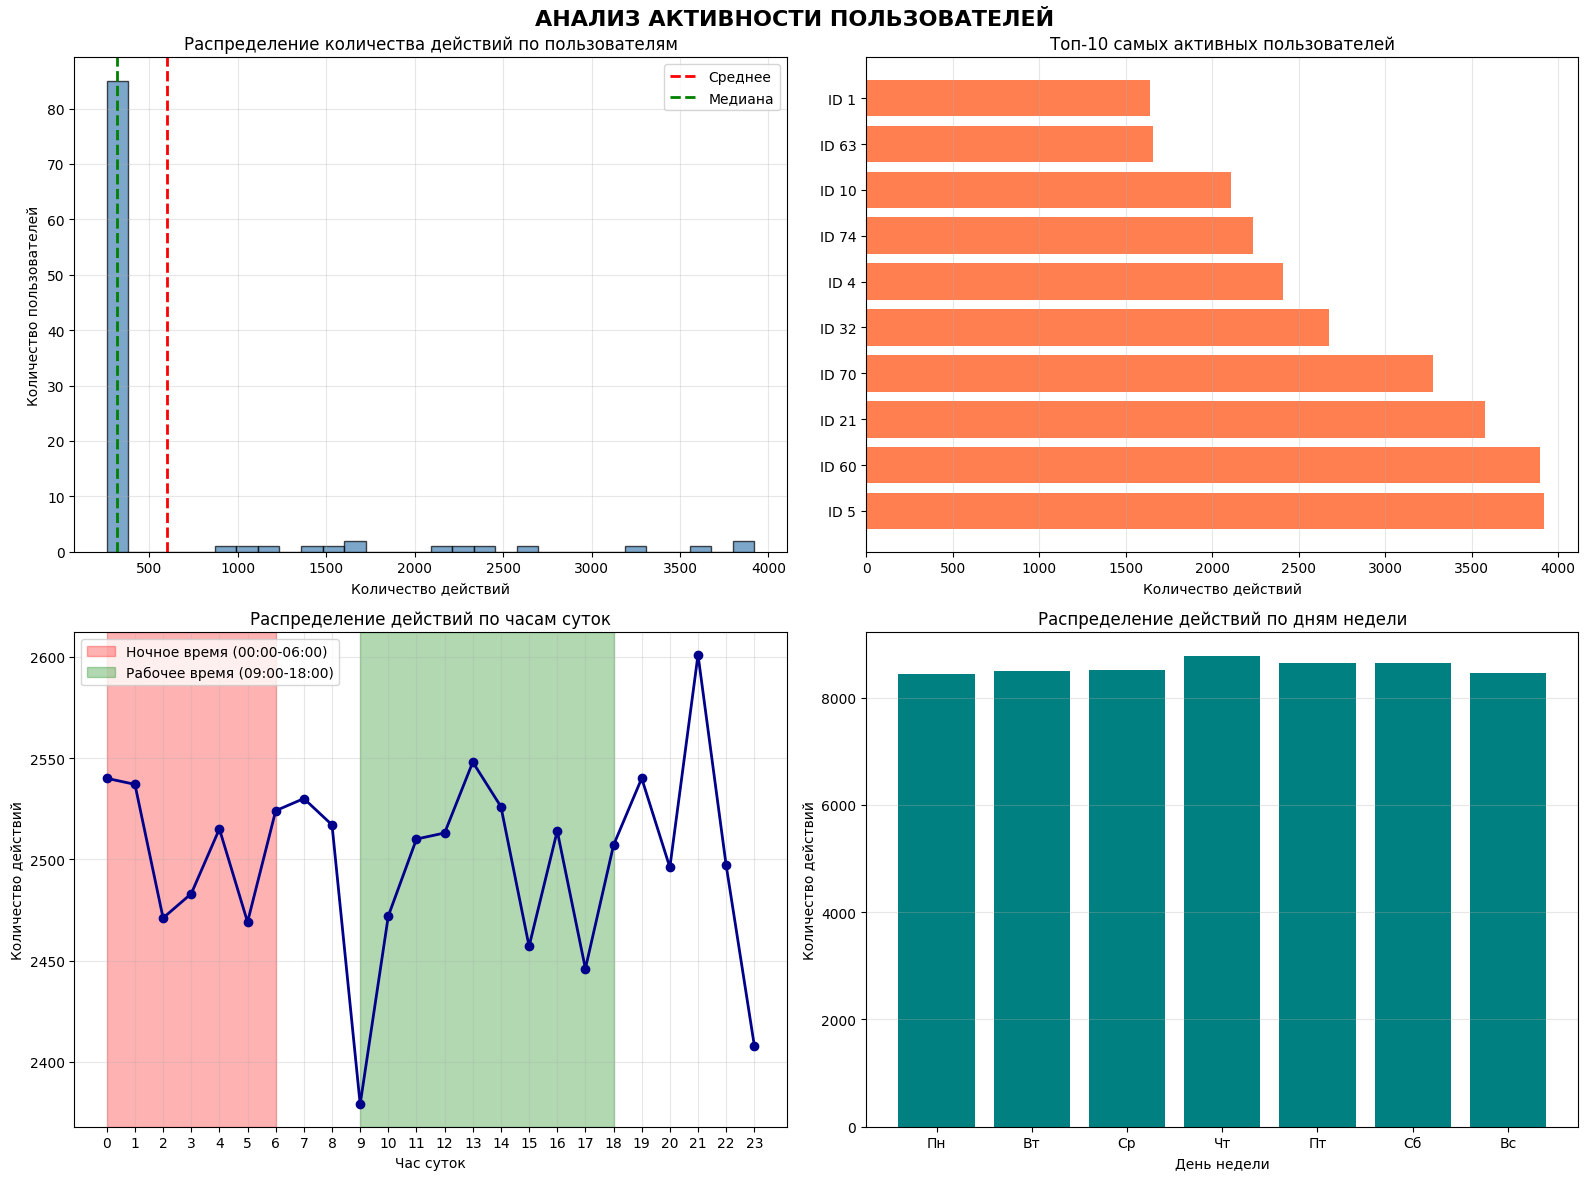

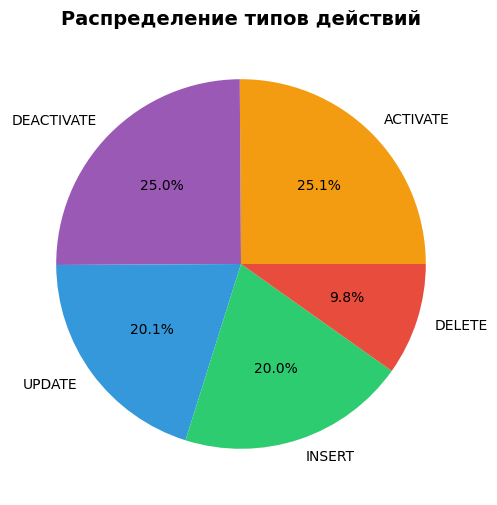

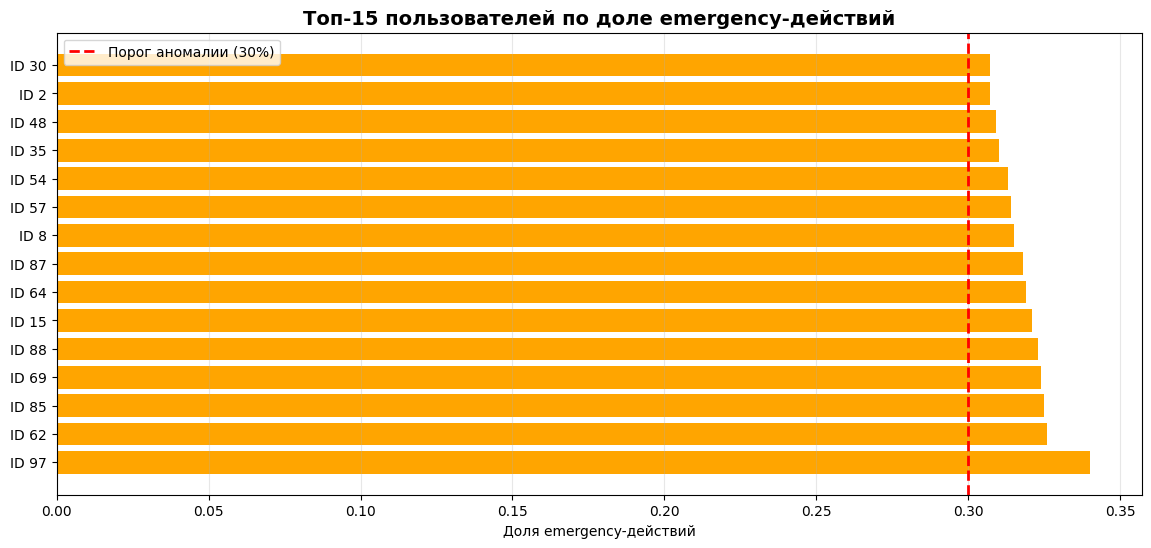

In [ ]:
import matplotlib.pyplot as plt

# Распределение количества действий по пользователям
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('АНАЛИЗ АКТИВНОСТИ ПОЛЬЗОВАТЕЛЕЙ', fontsize=16, fontweight='bold')

# График 1: Гистограмма количества действий
axes[0, 0].hist(user_stats['total_actions'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(user_stats['total_actions'].mean(), color='red', linestyle='--', linewidth=2, label='Среднее')
axes[0, 0].axvline(user_stats['total_actions'].median(), color='green', linestyle='--', linewidth=2, label='Медиана')
axes[0, 0].set_xlabel('Количество действий')
axes[0, 0].set_ylabel('Количество пользователей')
axes[0, 0].set_title('Распределение количества действий по пользователям')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# График 2: Топ-10 самых активных пользователей
top_10_users = user_stats.nlargest(10, 'total_actions')
axes[0, 1].barh(range(len(top_10_users)), top_10_users['total_actions'], color='coral')
axes[0, 1].set_yticks(range(len(top_10_users)))
axes[0, 1].set_yticklabels([f'ID {idx}' for idx in top_10_users.index])
axes[0, 1].set_xlabel('Количество действий')
axes[0, 1].set_title('Топ-10 самых активных пользователей')
axes[0, 1].grid(alpha=0.3, axis='x')

# График 3: Распределение по часам суток
hourly_dist = df.groupby('hour').size()
axes[1, 0].plot(hourly_dist.index, hourly_dist.values, marker='o', linewidth=2, color='darkblue')
axes[1, 0].axvspan(0, 6, alpha=0.3, color='red', label='Ночное время (00:00-06:00)')
axes[1, 0].axvspan(9, 18, alpha=0.3, color='green', label='Рабочее время (09:00-18:00)')
axes[1, 0].set_xlabel('Час суток')
axes[1, 0].set_ylabel('Количество действий')
axes[1, 0].set_title('Распределение действий по часам суток')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(range(24))

# График 4: Распределение по дням недели
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
daily_dist = df.groupby('day_of_week').size()
axes[1, 1].bar([days_map[d] for d in daily_dist.index], daily_dist.values, color='teal')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Количество действий')
axes[1, 1].set_title('Распределение действий по дням недели')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Распределение типов действий
plt.figure(figsize=(10, 6))
action_colors = {'INSERT': '#2ecc71', 'UPDATE': '#3498db', 'DELETE': '#e74c3c',
                 'ACTIVATE': '#f39c12', 'DEACTIVATE': '#9b59b6'}
df['action_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=[action_colors.get(x, '#95a5a6') for x in df['action_type'].value_counts().index])
plt.title('Распределение типов действий', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

# Emergency-режим по пользователям
plt.figure(figsize=(14, 6))
emergency_by_user = user_stats.nlargest(15, 'emergency_ratio')
plt.barh(range(len(emergency_by_user)), emergency_by_user['emergency_ratio'], color='orange')
plt.yticks(range(len(emergency_by_user)), [f'ID {idx}' for idx in emergency_by_user.index])
plt.xlabel('Доля emergency-действий')
plt.title('Топ-15 пользователей по доле emergency-действий', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.axvline(x=0.3, color='red', linestyle='--', linewidth=2, label='Порог аномалии (30%)')
plt.legend()
plt.show()

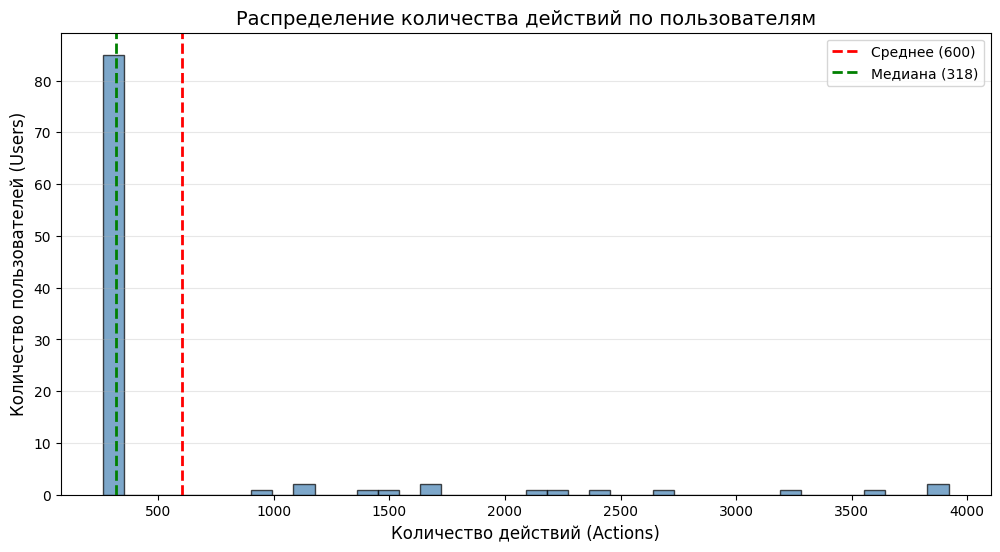

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Гистограмма (bins=40 для детализации, так как разброс большой)
plt.hist(user_stats['total_actions'], bins=40, color='steelblue', alpha=0.7, edgecolor='black')

# Линии среднего и медианы
plt.axvline(user_stats['total_actions'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее ({user_stats["total_actions"].mean():.0f})')
plt.axvline(user_stats['total_actions'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана ({user_stats["total_actions"].median():.0f})')

# Оформление
plt.title('Распределение количества действий по пользователям', fontsize=14)
plt.xlabel('Количество действий (Actions)', fontsize=12)
plt.ylabel('Количество пользователей (Users)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

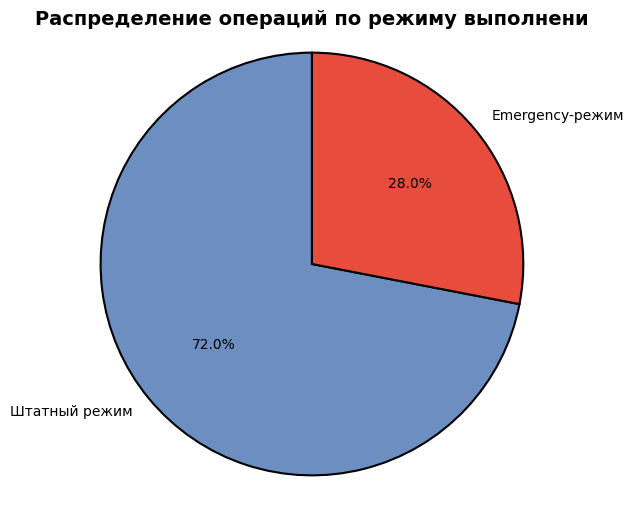

In [ ]:
import matplotlib.pyplot as plt

# Считаем количество 0 (обычные) и 1 (emergency)
emergency_counts = df['is_emergency'].value_counts()

# Переименуем подписи для легенды
labels = ['Штатный режим', 'Emergency-режим']
colors = ['#6c8ec0', '#e74c3c']

plt.figure(figsize=(6, 6))
plt.pie(
    emergency_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

plt.title('Распределение операций по режиму выполнени', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

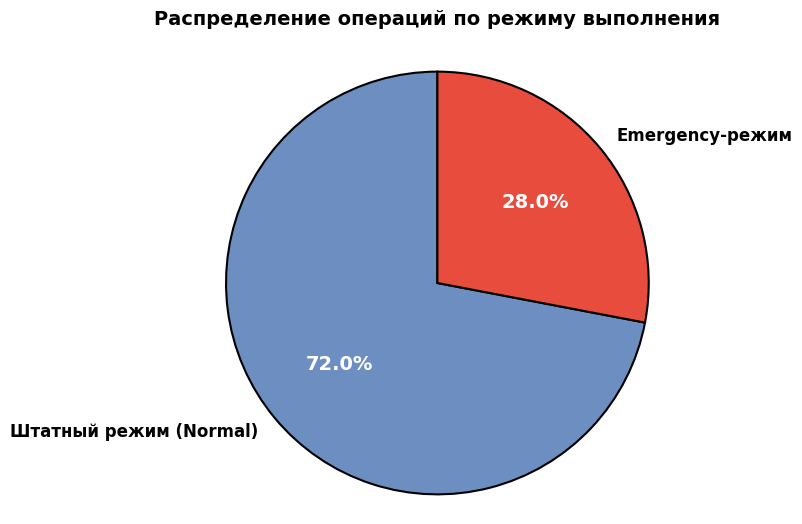

In [ ]:
import matplotlib.pyplot as plt

# Данные для диаграммы
labels = ['Штатный режим (Normal)', 'Emergency-режим']
sizes = [72.0, 28.0]  # 100% - 28% = 72%
colors = ['#6c8ec0', '#e74c3c']  # Синий для нормы, Красный для тревоги

# Настройка размера фигуры
plt.figure(figsize=(6, 6))

# Построение диаграммы
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',  # Показывает проценты с одним знаком после запятой
    startangle=90,      # Поворот диаграммы
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5} # Черные границы секторов
)

# Улучшение шрифтов
plt.setp(texts, size=12, weight="bold")
plt.setp(autotexts, size=14, weight="bold", color="white")

plt.title('Распределение операций по режиму выполнения', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')  # Делает диаграмму круглой, а не овальной

plt.show()

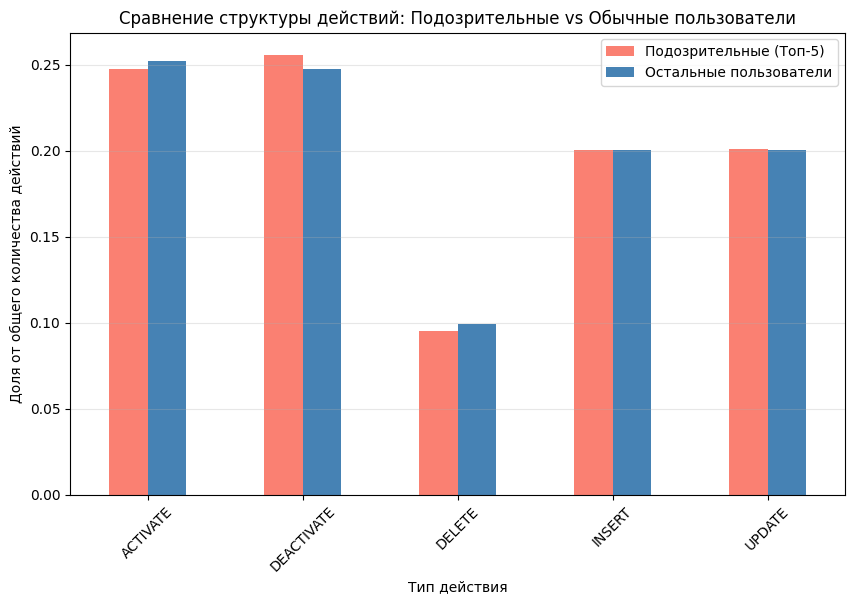

In [ ]:
# Получаем ID топ-5 рисковых пользователей
top_5_ids = user_stats.nlargest(5, 'risk_score').index

# Считаем распределение типов действий для рисковых
risky_actions = df[df['user_id'].isin(top_5_ids)]['action_type'].value_counts(normalize=True)
# Считаем распределение для остальных (фоновых пользователей)
normal_actions = df[~df['user_id'].isin(top_5_ids)]['action_type'].value_counts(normalize=True)

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Подозрительные (Топ-5)': risky_actions,
    'Остальные пользователи': normal_actions
}).fillna(0)

# Строим график
comparison_df.plot(kind='bar', figsize=(10, 6), color=['salmon', 'steelblue'])
plt.title('Сравнение структуры действий: Подозрительные vs Обычные пользователи')
plt.ylabel('Доля от общего количества действий')
plt.xlabel('Тип действия')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# ***5. Выявление аномалий***
Используем межквартильный размах (IQR) для статистического выявления пользователей с аномально высокой активностью.
Данный метод был выбран, так как данные о пользовательской активности в системах аудита редко имеют нормальное распределение: Большинство пользователей совершают мало действий, Небольшая группа (администраторы, дежурные) — много действий; IQR использует медиану и квартили, которые нечувствительны к выбросам.


In [ ]:
# Расчет квартилей для количества действий
Q1 = user_stats['total_actions'].quantile(0.25)
Q3 = user_stats['total_actions'].quantile(0.75)
IQR = Q3 - Q1

# Границы выбросов по методу Tukey [2]
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"СТАТИСТИКА РАСПРЕДЕЛЕНИЯ (количество действий):")
print(f"   • Q1 (25-й перцентиль): {Q1:.2f}")
print(f"   • Q3 (75-й перцентиль): {Q3:.2f}")
print(f"   • IQR (межквартильный размах): {IQR:.2f}")
print(f"   • Нижняя граница выбросов: {lower_bound:.2f}")
print(f"   • Верхняя граница выбросов: {upper_bound:.2f}")

# Выявление пользователей-выбросов
outliers_actions = user_stats[user_stats['total_actions'] > upper_bound]

print(f"ПОЛЬЗОВАТЕЛИ С АНОМАЛЬНО ВЫСОКОЙ АКТИВНОСТЬЮ:")
print(f"   • Количество: {len(outliers_actions)}")
if len(outliers_actions) > 0:
    display(outliers_actions[['total_actions', 'emergency_ratio', 'critical_ratio']].sort_values('total_actions', ascending=False))

# Выявление аномалий по другим метрикам
# Emergency-режим
emergency_outliers = user_stats[user_stats['emergency_ratio'] > 0.30]
print(f"\nПОЛЬЗОВАТЕЛИ С ВЫСОКОЙ ДОЛЕЙ EMERGENCY (>30%): {len(emergency_outliers)}")

# Отсутствие комментариев при критических действиях (> 50%)
critical_actions = df[df['is_critical']]

if not critical_actions.empty:
    # Общее количество критических действий на пользователя
    total_critical_by_user = critical_actions.groupby('user_id').size()

    # Количество критических действий БЕЗ комментария на пользователя
    no_comment_critical_by_user = critical_actions[~critical_actions['has_comment']].groupby('user_id').size()

    # Приводим индексы к общему виду (если у пользователя все действия с комментарием,
    # в no_comment_critical_by_user его не будет, поэтому заполняем 0)
    no_comment_critical_by_user = no_comment_critical_by_user.reindex(total_critical_by_user.index, fill_value=0)

    # Расчет доли
    no_comment_ratio = no_comment_critical_by_user / total_critical_by_user

    # Фильтр: доля без комментариев более 50%
    no_comment_outliers = no_comment_ratio[no_comment_ratio > 0.5]
else:
    # Если критических действий вообще нет в датасете
    no_comment_outliers = pd.Series(dtype=float)

print(f"ПОЛЬЗОВАТЕЛИ С >50% КРИТИЧЕСКИХ ДЕЙСТВИЙ БЕЗ КОММЕНТАРИЯ: {len(no_comment_outliers)}")


# Ночная активность
night_by_user = df[df['is_night']].groupby('user_id').size()
night_ratio = night_by_user / user_stats['total_actions']
night_outliers = night_ratio[night_ratio > 0.25]
print(f"ПОЛЬЗОВАТЕЛИ С >25% НОЧНЫХ ДЕЙСТВИЙ: {len(night_outliers)}")

# Сохранение списков аномальных пользователей
anomaly_lists = {
    'high_activity': outliers_actions.index.tolist(),
    'high_emergency': emergency_outliers.index.tolist(),
    'no_comment_critical': no_comment_outliers.index.tolist(),
    'high_night_activity': night_outliers.index.tolist()
}


СТАТИСТИКА РАСПРЕДЕЛЕНИЯ (количество действий):
   • Q1 (25-й перцентиль): 305.00
   • Q3 (75-й перцентиль): 332.50
   • IQR (межквартильный размах): 27.50
   • Нижняя граница выбросов: 263.75
   • Верхняя граница выбросов: 373.75
ПОЛЬЗОВАТЕЛИ С АНОМАЛЬНО ВЫСОКОЙ АКТИВНОСТЬЮ:
   • Количество: 15


,total_actions,emergency_ratio,critical_ratio
user_id,,,
5,3920,0.282,0.351
60,3894,0.282,0.350
21,3575,0.286,0.350
70,3278,0.279,0.350
32,2674,0.267,0.353
4,2407,0.285,0.349
74,2235,0.285,0.341
10,2109,0.294,0.337
63,1659,0.275,0.354



ПОЛЬЗОВАТЕЛИ С ВЫСОКОЙ ДОЛЕЙ EMERGENCY (>30%): 17
ПОЛЬЗОВАТЕЛИ С >50% КРИТИЧЕСКИХ ДЕЙСТВИЙ БЕЗ КОММЕНТАРИЯ: 100
ПОЛЬЗОВАТЕЛИ С >25% НОЧНЫХ ДЕЙСТВИЙ: 52


# ***6. РАСЧЕТ COMPOSITE RISK SCORE***



ТОП-10 ПОЛЬЗОВАТЕЛЕЙ ПО УРОВНЮ РИСКА:


,total_actions,emergency_ratio,commented_ratio,risk_score
user_id,,,,
5,3920,0.282,0.492,0.623
60,3894,0.282,0.496,0.613
21,3575,0.286,0.503,0.605
18,331,0.284,0.483,0.566
70,3278,0.279,0.496,0.565
2,309,0.307,0.492,0.553
39,311,0.257,0.418,0.537
57,325,0.314,0.514,0.523
32,2674,0.267,0.491,0.520



РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ РИСКА:
   🟡 СРЕДНИЙ: 81 пользователей (81.0%)
   🟠 ВЫСОКИЙ: 12 пользователей (12.0%)
   🟢 НИЗКИЙ: 7 пользователей (7.0%)


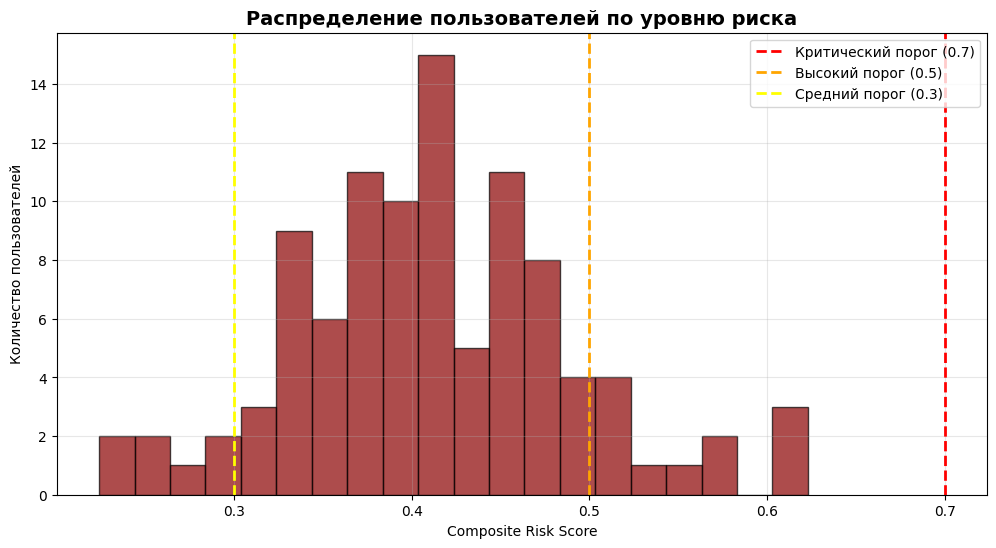

In [ ]:

# Функция для нормализации метрик (Min-Max scaling)
def normalize_series(series):
    """Нормализует серию к диапазону [0, 1]"""
    min_val = series.min()
    max_val = series.max()
    if max_val - min_val == 0:
        return pd.Series(0, index=series.index)
    return (series - min_val) / (max_val - min_val)

# Нормализация ключевых метрик
user_stats['norm_actions'] = normalize_series(user_stats['total_actions'])
user_stats['norm_emergency'] = normalize_series(user_stats['emergency_ratio'])
user_stats['norm_no_comment'] = normalize_series(1 - user_stats['commented_ratio'])  # Инвертируем
user_stats['norm_night'] = normalize_series(1 - user_stats['business_ratio'])  # Инвертируем
user_stats['norm_critical'] = normalize_series(user_stats['critical_ratio'])

# Расчет взвешенного риска
# Веса основаны на критичности каждого фактора для безопасности
weights = {
    'norm_actions': 0.20,      # Высокая активность
    'norm_emergency': 0.25,    # Emergency-режим (высокий вес!)
    'norm_no_comment': 0.20,   # Отсутствие комментариев
    'norm_night': 0.15,        # Ночная активность
    'norm_critical': 0.20      # Критические действия
}

user_stats['risk_score'] = (
    user_stats['norm_actions'] * weights['norm_actions'] +
    user_stats['norm_emergency'] * weights['norm_emergency'] +
    user_stats['norm_no_comment'] * weights['norm_no_comment'] +
    user_stats['norm_night'] * weights['norm_night'] +
    user_stats['norm_critical'] * weights['norm_critical']
).round(3)

# Ранжирование пользователей по риску
risk_ranking = user_stats.sort_values('risk_score', ascending=False)

print("\nТОП-10 ПОЛЬЗОВАТЕЛЕЙ ПО УРОВНЮ РИСКА:")
display(risk_ranking[['total_actions', 'emergency_ratio', 'commented_ratio', 'risk_score']].head(10))

# Категоризация по уровням риска
def risk_category(score):
    """Категоризирует риск по пороговым значениям"""
    if score >= 0.7:
        return '🔴 КРИТИЧЕСКИЙ'
    elif score >= 0.5:
        return '🟠 ВЫСОКИЙ'
    elif score >= 0.3:
        return '🟡 СРЕДНИЙ'
    else:
        return '🟢 НИЗКИЙ'

user_stats['risk_category'] = user_stats['risk_score'].apply(risk_category)

print("\nРАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ РИСКА:")
risk_dist = user_stats['risk_category'].value_counts()
for category, count in risk_dist.items():
    print(f"   {category}: {count} пользователей ({count/len(user_stats)*100:.1f}%)")

# 7.6. Визуализация распределения риска
plt.figure(figsize=(12, 6))
plt.hist(user_stats['risk_score'], bins=20, color='darkred', alpha=0.7, edgecolor='black')
plt.axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Критический порог (0.7)')
plt.axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Высокий порог (0.5)')
plt.axvline(x=0.3, color='yellow', linestyle='--', linewidth=2, label='Средний порог (0.3)')
plt.xlabel('Composite Risk Score')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по уровню риска', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ***7. Детальный анализ подозрительных пользователей***
Для пользователей с высоким риском проводим углубленный анализ:
временные паттерны, типы действий, комментарии, объекты.

In [ ]:
# Выборка пользователей для детального анализа (риск >= 0.5)
suspicious_users = risk_ranking[risk_ranking['risk_score'] >= 0.5].index.tolist()

print(f"\n ПОЛЬЗОВАТЕЛИ ДЛЯ ДЕТАЛЬНОГО АНАЛИЗА: {len(suspicious_users)}")
print(f"   ID: {suspicious_users[:10]}{'...' if len(suspicious_users) > 10 else ''}")

# 8.2. Функция для детального отчета по пользователю
def analyze_user(user_id, df_data):
    """
    Генерирует детальный отчет по конкретному пользователю.
    Возвращает словарь с метриками и паттернами.
    """
    user_data = df_data[df_data['user_id'] == user_id].copy()

    if len(user_data) == 0:
        return None

    report = {
        'user_id': user_id,
        'total_actions': len(user_data),
        'date_range': f"{user_data['action_datetime'].min()} — {user_data['action_datetime'].max()}",
        'action_types': user_data['action_type'].value_counts().to_dict(),
        'object_types': user_data['object_type'].value_counts().to_dict(),
        'emergency_count': user_data['is_emergency'].sum(),
        'emergency_ratio': (user_data['is_emergency'].sum() / len(user_data)).round(3),
        'night_actions': user_data['is_night'].sum(),
        'night_ratio': (user_data['is_night'].sum() / len(user_data)).round(3),
        'weekend_actions': user_data['is_weekend'].sum(),
        'weekend_ratio': (user_data['is_weekend'].sum() / len(user_data)).round(3),
        'no_comment_count': (~user_data['has_comment']).sum(),
        'no_comment_ratio': ((~user_data['has_comment']).sum() / len(user_data)).round(3),
        'critical_actions': user_data['is_critical'].sum(),
        'critical_ratio': (user_data['is_critical'].sum() / len(user_data)).round(3),
        'unique_objects': user_data['object_id'].nunique(),
        'comments_sample': user_data[user_data['has_comment']]['comment'].head(5).tolist()
    }

    return report

# Генерация отчетов для топ-5 подозрительных пользователей
print("\n" + "=" * 80)
print("ОТЧЕТЫ ПО ТОП-5 ПОДОЗРИТЕЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ")
print("=" * 80)

detailed_reports = []

for idx, user_id in enumerate(suspicious_users[:5], 1):
    report = analyze_user(user_id, df)
    if report:
        detailed_reports.append(report)

        print(f"\n{'='*80}")
        print(f"ПОЛЬЗОВАТЕЛЬ #{idx}: ID {user_id}")
        print(f"{'='*80}")
        print(f"   Всего действий: {report['total_actions']}")
        print(f"   Период активности: {report['date_range']}")
        print(f"   Уникальных объектов: {report['unique_objects']}")
        print(f"\n   ВРЕМЕННЫЕ ПАТТЕРНЫ:")
        print(f"      • Ночные действия: {report['night_actions']} ({report['night_ratio']*100:.1f}%)")
        print(f"      • Выходные дни: {report['weekend_actions']} ({report['weekend_ratio']*100:.1f}%)")
        print(f"      • Emergency-режим: {report['emergency_count']} ({report['emergency_ratio']*100:.1f}%)")
        print(f"\n   КОММЕНТАРИИ:")
        print(f"      • Без комментария: {report['no_comment_count']} ({report['no_comment_ratio']*100:.1f}%)")
        if report['comments_sample']:
            print(f"      • Примеры комментариев: {report['comments_sample'][:3]}")
        print(f"\n   ТИПЫ ДЕЙСТВИЙ:")
        for action, count in report['action_types'].items():
            print(f"      • {action}: {count}")
        print(f"\n    ТИПЫ ОБЪЕКТОВ:")
        for obj, count in report['object_types'].items():
            print(f"      • {obj}: {count}")
        print(f"\n   КРИТИЧЕСКИЕ ДЕЙСТВИЯ: {report['critical_actions']} ({report['critical_ratio']*100:.1f}%)")




 ПОЛЬЗОВАТЕЛИ ДЛЯ ДЕТАЛЬНОГО АНАЛИЗА: 12
   ID: [5, 60, 21, 18, 70, 2, 39, 57, 32, 63]...

ОТЧЕТЫ ПО ТОП-5 ПОДОЗРИТЕЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ

ПОЛЬЗОВАТЕЛЬ #1: ID 5
   Всего действий: 3920
   Период активности: 2023-01-01 00:59:47 — 2026-02-15 16:16:02
   Уникальных объектов: 234

   ВРЕМЕННЫЕ ПАТТЕРНЫ:
      • Ночные действия: 1011 (25.8%)
      • Выходные дни: 1120 (28.6%)
      • Emergency-режим: 1104 (28.2%)

   КОММЕНТАРИИ:
      • Без комментария: 1993 (50.8%)
      • Примеры комментариев: ['Исправление опечатки', 'Актуализация версии', 'Создание нового элемента']

   ТИПЫ ДЕЙСТВИЙ:
      • DEACTIVATE: 1007
      • ACTIVATE: 986
      • UPDATE: 784
      • INSERT: 776
      • DELETE: 367

    ТИПЫ ОБЪЕКТОВ:
      • требование: 1354
      • отчет: 1007
      • ролевая модель: 783
      • нормативный акт: 776

   КРИТИЧЕСКИЕ ДЕЙСТВИЯ: 1374 (35.1%)

ПОЛЬЗОВАТЕЛЬ #2: ID 60
   Всего действий: 3894
   Период активности: 2023-01-01 01:02:51 — 2026-02-15 23:42:21
   Уникальных объектов: 264



# ***8. Выявление конкретных инцидентов***
Формируем список конкретных событий, требующих первоочередного внимания.
Приоритизация по критичности и потенциальному ущербу.

In [ ]:
# Приоритет 1: DELETE без комментария в нерабочее время
priority_1 = df[
    (df['action_type'] == 'DELETE') &
    (~df['has_comment']) &
    (~df['is_business_hours'])
].copy()

print(f"\n ПРИОРИТЕТ 1 (КРИТИЧЕСКИЙ): {len(priority_1)} событий")
print("   Критерии: DELETE без комментария в нерабочее время")
if len(priority_1) > 0:
    display(priority_1[['action_datetime', 'user_id', 'object_type', 'object_id', 'is_emergency']].head(10))

# Приоритет 2: Массовые действия одного пользователя за короткий период
# Группируем по пользователю и часу, ищем аномально высокую концентрацию
df['hour_bucket'] = df['action_datetime'].dt.floor('H')
hourly_activity = df.groupby(['user_id', 'hour_bucket']).size().reset_index(name='actions_per_hour')
priority_2 = hourly_activity[hourly_activity['actions_per_hour'] >= 5]

print(f"\nПРИОРИТЕТ 2 (ВЫСОКИЙ): {len(priority_2)} случаев массовой активности")
print("   Критерии: ≥5 действий одного пользователя за 1 час")
if len(priority_2) > 0:
    display(priority_2.sort_values('actions_per_hour', ascending=False).head(10))

# Приоритет 3: Изменения ролевых моделей в emergency-режиме
priority_3 = df[
    (df['object_type'] == 'ролевая модель') &
    (df['is_emergency'] == 1)
].copy()

print(f"\nПРИОРИТЕТ 3 (СРЕДНИЙ): {len(priority_3)} событий")
print("   Критерии: Изменения ролевых моделей в emergency-режиме")
if len(priority_3) > 0:
    display(priority_3[['action_datetime', 'user_id', 'action_type', 'object_id']].head(10))

# Приоритет 4: Повторные изменения одного объекта
object_changes = df.groupby(['object_id', 'object_type']).size().reset_index(name='change_count')
priority_4 = object_changes[object_changes['change_count'] >= 5]

print(f"\n ПРИОРИТЕТ 4 (ПЛАНОВЫЙ): {len(priority_4)} объектов с частыми изменениями")
print("   Критерии: ≥5 изменений одного объекта")
if len(priority_4) > 0:
    display(priority_4.sort_values('change_count', ascending=False).head(10))


 ПРИОРИТЕТ 1 (КРИТИЧЕСКИЙ): 0 событий
   Критерии: DELETE без комментария в нерабочее время

ПРИОРИТЕТ 2 (ВЫСОКИЙ): 1 случаев массовой активности
   Критерии: ≥5 действий одного пользователя за 1 час


/tmp/ipykernel_53305/2953665680.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['hour_bucket'] = df['action_datetime'].dt.floor('H')


,user_id,hour_bucket,actions_per_hour
38279,60,2025-06-23 02:00:00,5



ПРИОРИТЕТ 3 (СРЕДНИЙ): 0 событий
   Критерии: Изменения ролевых моделей в emergency-режиме

 ПРИОРИТЕТ 4 (ПЛАНОВЫЙ): 311 объектов с частыми изменениями
   Критерии: ≥5 изменений одного объекта


,object_id,object_type,change_count
5167,8351,требование,358
16176,25615,требование,348
684,1171,требование,346
7439,11946,требование,334
2436,3956,требование,297
6654,10727,требование,291
5165,8351,отчет,281
1320,2156,требование,278
9231,14703,требование,277
6113,9902,требование,277


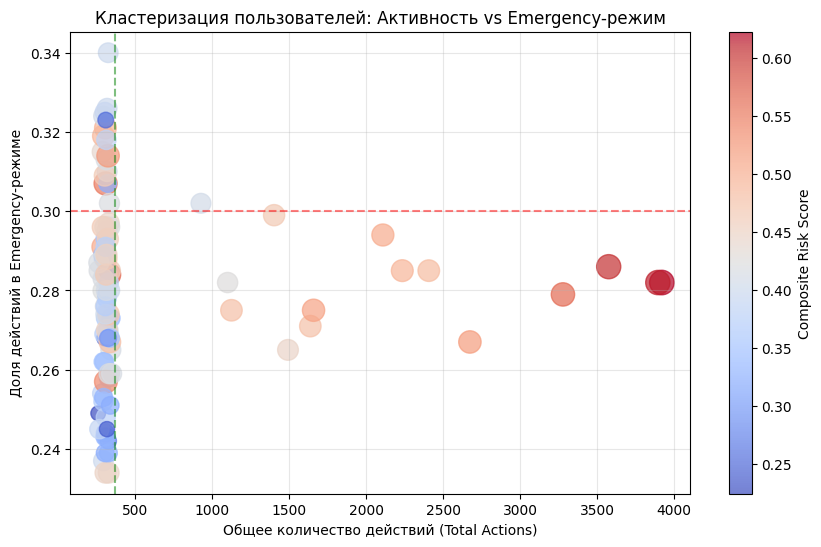

In [ ]:
plt.figure(figsize=(10, 6))
# Размер точки зависит от риска, цвет тоже
scatter = plt.scatter(
    user_stats['total_actions'],
    user_stats['emergency_ratio'],
    c=user_stats['risk_score'],
    cmap='coolwarm',
    s=user_stats['risk_score']*500, # Размер точки пропорционален риску
    alpha=0.7
)
plt.colorbar(scatter, label='Composite Risk Score')
plt.xlabel('Общее количество действий (Total Actions)')
plt.ylabel('Доля действий в Emergency-режиме')
plt.title('Кластеризация пользователей: Активность vs Emergency-режим')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.3, color='r', linestyle='--', alpha=0.5) # Порог emergency
plt.axvline(x=373, color='g', linestyle='--', alpha=0.5) # Порог IQR
plt.show()

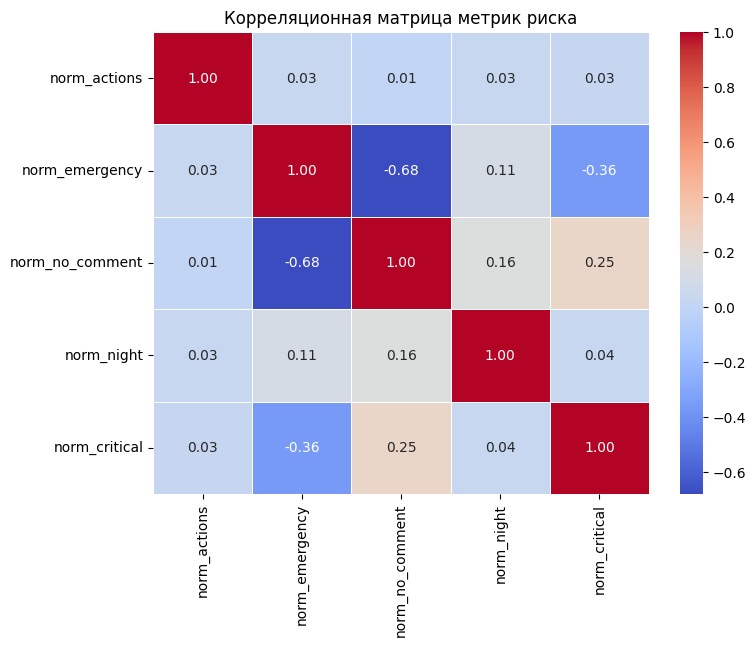

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Выбираем только нормализованные метрики, которые пошли в CRS
metrics = ['norm_actions', 'norm_emergency', 'norm_no_comment', 'norm_night', 'norm_critical']
corr_matrix = user_stats[metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Корреляционная матрица метрик риска')
plt.show()

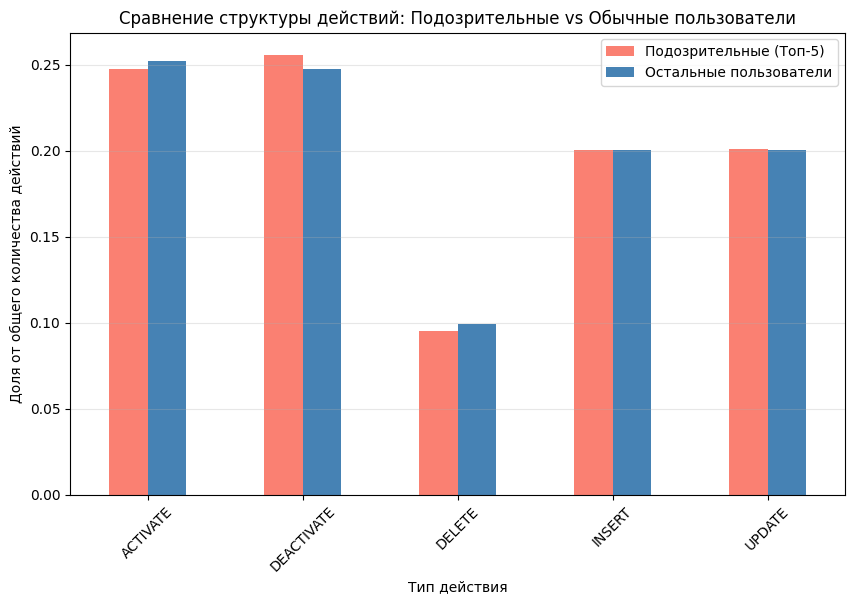

In [ ]:
# Получаем ID топ-5 рисковых пользователей
top_5_ids = user_stats.nlargest(5, 'risk_score').index

# Считаем распределение типов действий для рисковых
risky_actions = df[df['user_id'].isin(top_5_ids)]['action_type'].value_counts(normalize=True)
# Считаем распределение для остальных (фоновых пользователей)
normal_actions = df[~df['user_id'].isin(top_5_ids)]['action_type'].value_counts(normalize=True)

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Подозрительные (Топ-5)': risky_actions,
    'Остальные пользователи': normal_actions
}).fillna(0)

# Строим график
comparison_df.plot(kind='bar', figsize=(10, 6), color=['salmon', 'steelblue'])
plt.title('Сравнение структуры действий: Подозрительные vs Обычные пользователи')
plt.ylabel('Доля от общего количества действий')
plt.xlabel('Тип действия')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Убедимся, что night_ratio существует
user_stats['night_ratio'] = df.groupby('user_id')['is_night'].mean()

# 1. Подготавливаем признаки
features_for_ml = ['total_actions', 'emergency_ratio', 'commented_ratio',
                   'critical_ratio', 'night_ratio']
X = user_stats[features_for_ml].copy()

# 2. Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Инициализируем модель
iso_forest = IsolationForest(contamination=0.12, random_state=42, n_estimators=100)

# 🔑 ВАЖНО: Обучаем модель на данных
iso_forest.fit(X_scaled)

# 4. Получаем оценки и предсказания
user_stats['ml_anomaly_score'] = iso_forest.decision_function(X_scaled)
user_stats['ml_prediction'] = iso_forest.predict(X_scaled)  # 1 = норма, -1 = аномалия

# 5. Сравниваем с CRS
print(f"\nСовпадение методов: {(user_stats['ml_prediction'] == -1).sum()} пользователей помечены как аномалии")
print(f"Топ-5 по ML-скорингу (ниже = более аномально):")
display(user_stats.nsmallest(5, 'ml_anomaly_score')[['total_actions', 'emergency_ratio', 'ml_anomaly_score', 'risk_score']])


Совпадение методов: 12 пользователей помечены как аномалии
Топ-5 по ML-скорингу (ниже = более аномально):


,total_actions,emergency_ratio,ml_anomaly_score,risk_score
user_id,,,,
97,326,0.340,-0.107857,0.399
88,310,0.323,-0.049917,0.255
5,3920,0.282,-0.030272,0.623
54,313,0.313,-0.020732,0.416
67,310,0.248,-0.016154,0.377


ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ

1. ТЕСТ ШАПИРО-УИЛКА:
--------------------------------------------------------------------------------
Признак                   W-статистика    p-value         Нормальное?    
--------------------------------------------------------------------------------
total_actions             0.4405          0.0000          Нет            
emergency_ratio           0.9844          0.2853          Да             
commented_ratio           0.9933          0.9066          Да             
critical_ratio            0.9765          0.0705          Да             
night_ratio               0.9642          0.0082          Нет            

Вывод: При p-value < 0.05 гипотеза о нормальности отвергается


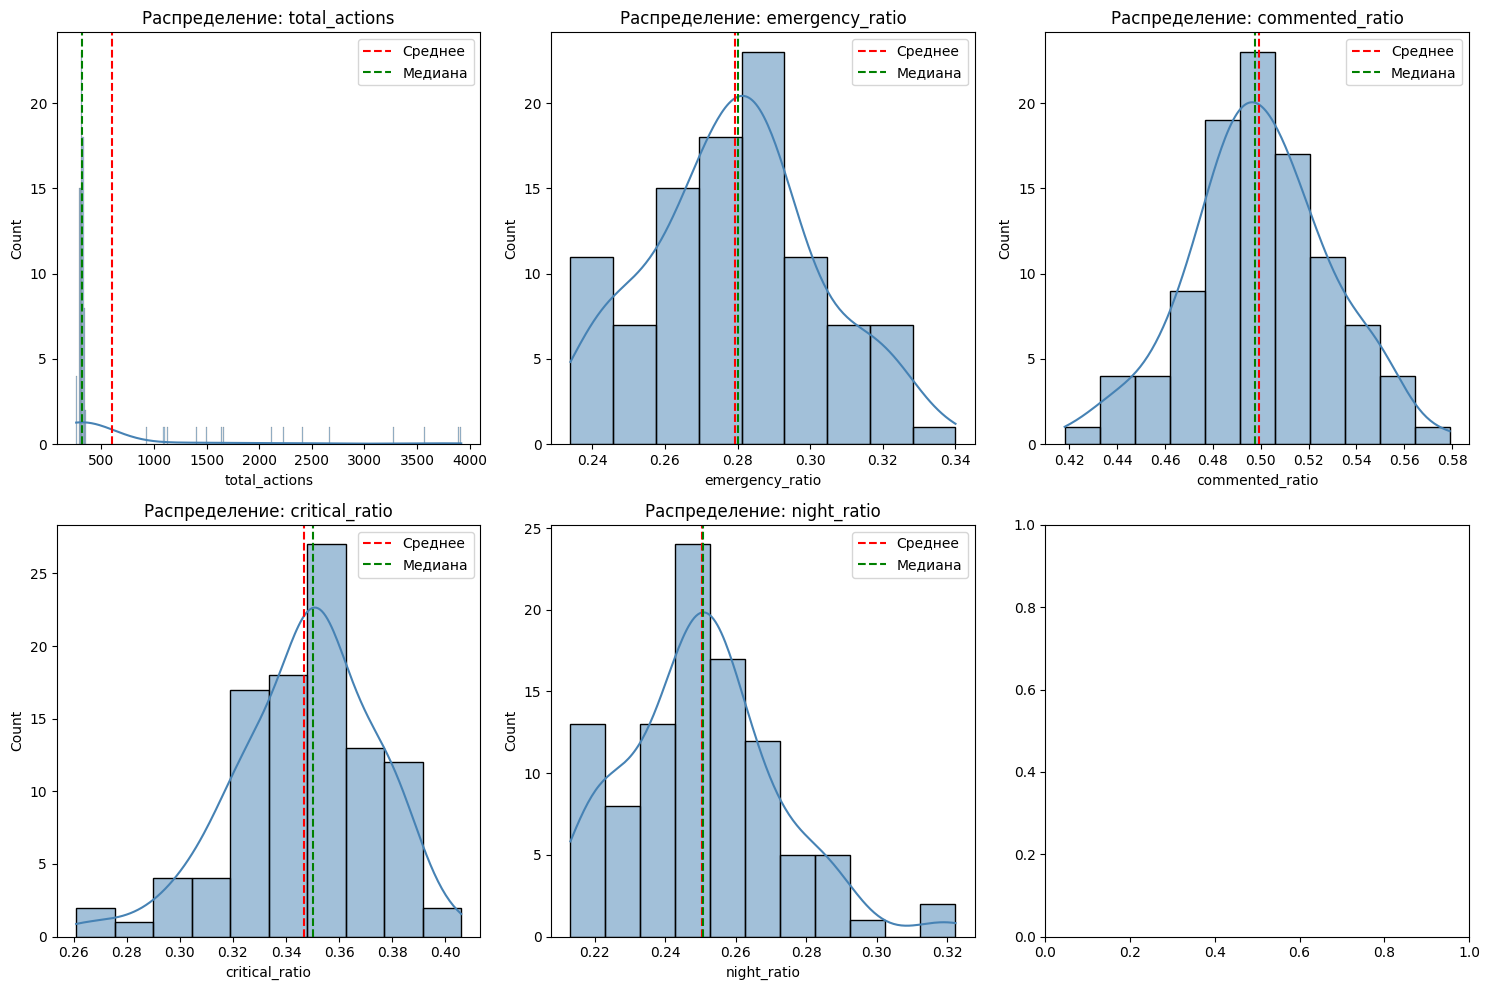

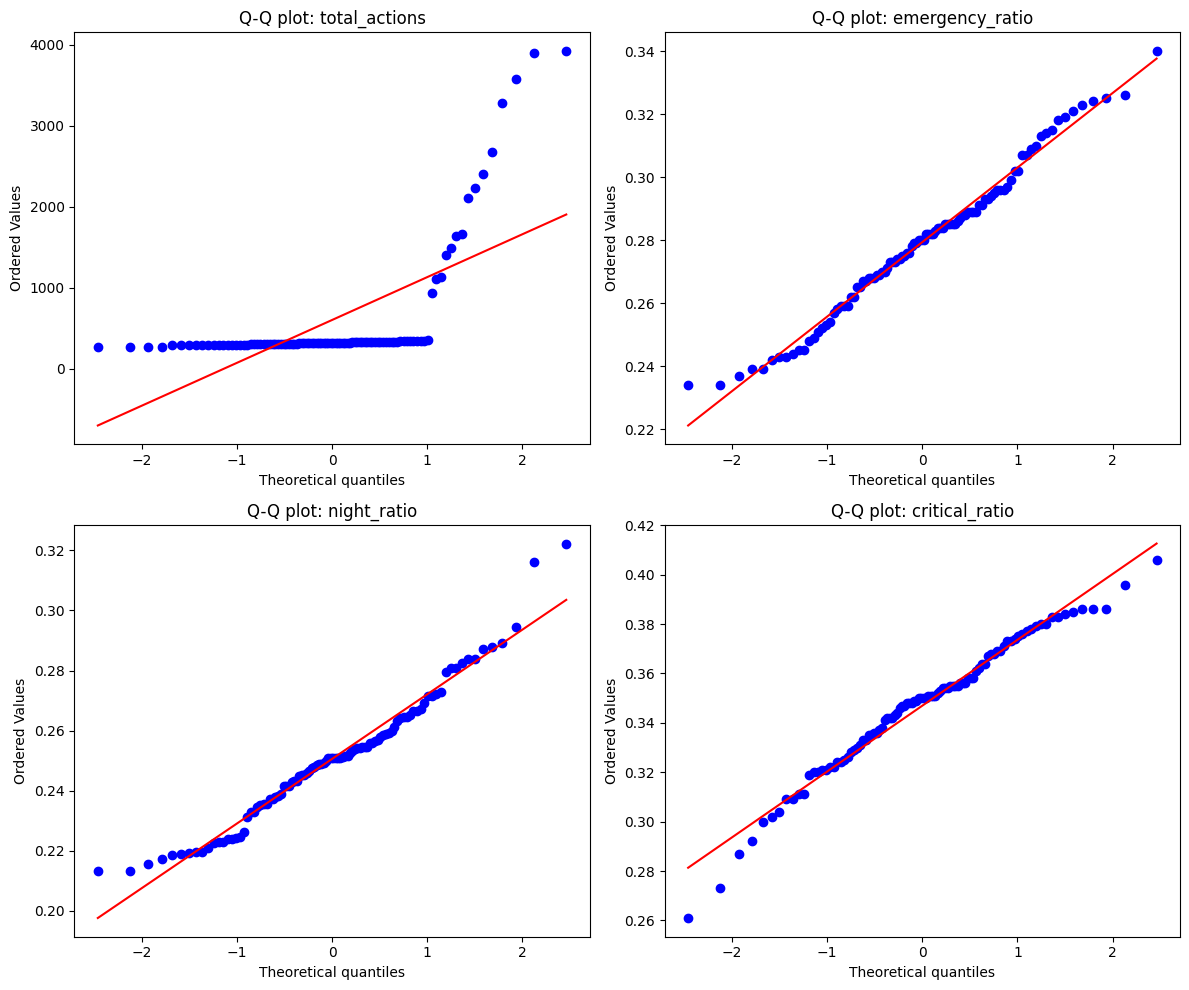


2. ВИЗУАЛЬНЫЙ АНАЛИЗ:
--------------------------------------------------------------------------------
Проверьте гистограммы и Q-Q plots:
• Если точки на Q-Q plot лежат на прямой - распределение близко к нормальному
• Сильные отклонения от прямой указывают на отклонение от нормальности


In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Признаки для проверки
features_to_check = ['total_actions', 'emergency_ratio', 'commented_ratio',
                     'critical_ratio', 'night_ratio']

print("=" * 80)
print("ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ")
print("=" * 80)

# Тест Шапиро-Уилка
print("\n1. ТЕСТ ШАПИРО-УИЛКА:")
print("-" * 80)
print(f"{'Признак':<25} {'W-статистика':<15} {'p-value':<15} {'Нормальное?':<15}")
print("-" * 80)

normality_results = {}
for feature in features_to_check:
    stat, p_value = stats.shapiro(user_stats[feature])
    is_normal = p_value > 0.05
    normality_results[feature] = is_normal
    print(f"{feature:<25} {stat:<15.4f} {p_value:<15.4f} {'Да' if is_normal else 'Нет':<15}")

print("\nВывод: При p-value < 0.05 гипотеза о нормальности отвергается")

# Визуализация распределений
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_check):
    # Гистограмма с KDE
    sns.histplot(user_stats[feature], kde=True, ax=axes[idx], color='steelblue')
    axes[idx].axvline(user_stats[feature].mean(), color='red', linestyle='--', label='Среднее')
    axes[idx].axvline(user_stats[feature].median(), color='green', linestyle='--', label='Медиана')
    axes[idx].set_title(f'Распределение: {feature}')
    axes[idx].legend()

    # Добавляем Q-Q plot
    # (можно добавить отдельным графиком если нужно)

plt.tight_layout()
plt.show()

# Q-Q plot для ключевых признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

key_features = ['total_actions', 'emergency_ratio', 'night_ratio', 'critical_ratio']
for idx, feature in enumerate(key_features):
    stats.probplot(user_stats[feature], dist="norm", plot=axes[idx])
    axes[idx].set_title(f'Q-Q plot: {feature}')

plt.tight_layout()
plt.show()

print("\n2. ВИЗУАЛЬНЫЙ АНАЛИЗ:")
print("-" * 80)
print("Проверьте гистограммы и Q-Q plots:")
print("• Если точки на Q-Q plot лежат на прямой - распределение близко к нормальному")
print("• Сильные отклонения от прямой указывают на отклонение от нормальности")
print("=" * 80)